In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="your_api_key")
project = rf.workspace("cybertech-qde01").project("waste-classification-q75av-awlnx")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...


In [22]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

Change directory if needed

In [23]:
x_train = keras.utils.image_dataset_from_directory(directory ="/content/Waste-Classification-1/train",labels = "inferred", label_mode = "categorical", image_size = (224,224))
x_test = keras.utils.image_dataset_from_directory(directory ="/content/Waste-Classification-1/test",labels = "inferred", label_mode = "categorical", image_size = (224,224))
x_valid = keras.utils.image_dataset_from_directory(directory ="/content/Waste-Classification-1/valid",labels = "inferred", label_mode = "categorical", image_size = (224,224))

Found 1767 files belonging to 6 classes.
Found 253 files belonging to 6 classes.
Found 504 files belonging to 6 classes.


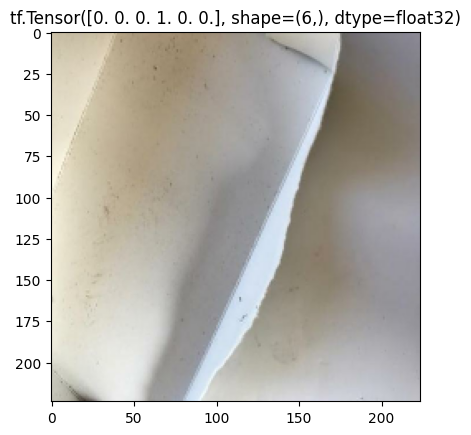

In [24]:
for image, label in x_train.take(1):
  plt.imshow(image[0].numpy().astype("uint8"))
  plt.title(label[0])

We apply data augmentation to increase size of the dataset, to prevent overfitting, since the data set is quite small.

In [25]:
augmentation = keras.Sequential([
    keras.layers.RandomFlip(mode="horizontal_and_vertical"),
    keras.layers.RandomRotation(0.15),
])

In [26]:
scaling = keras.Sequential(
    [
        keras.layers.Rescaling(scale =1./255)
    ]
)

In [27]:
convolution = keras.layers.Conv2D(
    filters = 32,
    kernel_size = (3,3),
    padding ="same",
    activation = "relu",
)

In [28]:
model = keras.Sequential([
    keras.Input(shape=(224,224,3)),
    augmentation,
    scaling,
    convolution,
    keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation ="relu"),
    tf.keras.layers.Dense(6, activation = "softmax")
])

In [29]:
model.compile(
    loss= keras.losses.CategoricalCrossentropy(),
    optimizer='adamw',
    metrics=['categorical_accuracy']
)

In [30]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 401408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    51,380,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,382,022 (196.01 MB)

 Trainable params: 51,382,022 (196.01 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
earlystop = keras.callbacks.EarlyStopping(monitor='val_loss',patience=6,restore_best_weights=True)
reducelr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=4,factor=0.1)
model.fit(x_train, epochs =20, validation_data = x_valid, callbacks=[earlystop,reducelr] )

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - categorical_accuracy: 0.2196 - loss: 15.3039 - val_categorical_accuracy: 0.3234 - val_loss: 1.6304 - learning_rate: 0.0010
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - categorical_accuracy: 0.3752 - loss: 1.5003 - val_categorical_accuracy: 0.4603 - val_loss: 1.3920 - learning_rate: 0.0010
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - categorical_accuracy: 0.4363 - loss: 1.4029 - val_categorical_accuracy: 0.4603 - val_loss: 1.3183 - learning_rate: 0.0010
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - categorical_accuracy: 0.4675 - loss: 1.3160 - val_categorical_accuracy: 0.5238 - val_loss: 1.2249 - learning_rate: 0.0010
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - categorical_accuracy: 0.5122 - loss: 1.2442 - val_categorical_accuracy: 0.5496 - val_loss: 1.1550 - learning_rate: 0.0010
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - categorical_accuracy: 0.5269 - loss: 1.2036 - val_categorical_accuracy:

In [32]:
print(model.evaluate(x_test))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - categorical_accuracy: 0.6166 - loss: 1.2476
[1.2476019859313965, 0.6166008114814758]


This simple CNN model has accuracy of about 60%. Considering baseline probability of random guessing the class is 16.7%(1 out of 6), it learns how to differentiate the images, but it's performence is not stellar.

In [33]:
backbone = keras.applications.EfficientNetB0(include_top = False, weights = 'imagenet', input_shape=(224, 224, 3))
backbone.trainable = False

model2 = keras.Sequential([
    keras.Input(shape=(224,224,3)),
    augmentation,
    backbone,
    keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation ="relu"),
    tf.keras.layers.Dense(6, activation = "softmax")
])

In [34]:
model2.compile(
    loss= keras.losses.CategoricalCrossentropy(),
    optimizer='adamw',
    metrics=['categorical_accuracy']
)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 401408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    51,380,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,146,068 (588.02 MB)

 Trainable params: 51,382,022 (196.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 102,764,046 (392.01 MB)

In [35]:
model2.fit(x_train, epochs =30, validation_data = x_valid, callbacks=[earlystop,reducelr] )

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - categorical_accuracy: 0.6746 - loss: 1.1686 - val_categorical_accuracy: 0.8016 - val_loss: 0.5500 - learning_rate: 0.0010
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - categorical_accuracy: 0.8274 - loss: 0.4809 - val_categorical_accuracy: 0.8333 - val_loss: 0.5005 - learning_rate: 0.0010
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - categorical_accuracy: 0.8619 - loss: 0.3662 - val_categorical_accuracy: 0.8294 - val_loss: 0.5934 - learning_rate: 0.0010
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - categorical_accuracy: 0.8732 - loss: 0.3502 - val_categorical_accuracy: 0.8433 - val_loss: 0.5126 - learning_rate: 0.0010
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - categorical_accuracy: 0.9055 - loss: 0.2551 - val_categorical_accuracy: 0.8175 - val_loss: 0.7061 - learning_rate: 0.0010
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - categorical_accuracy: 0.9230 - loss: 0.2213 - val_categorical_

In [36]:
print(model2.evaluate(x_test))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - categorical_accuracy: 0.8577 - loss: 0.5150
[0.5150135159492493, 0.8577075004577637]


CNN model with a backbone ("model2") significantly improves upon the simple one, and has a good accuracy of about 85%. The error rate is quite low, but probably still too high to use it comercially. Judging by the gap in accuracy on training and validation data, I would say the problem is overfitting and low amount of images in dataset.